# **AI Financial Market Data Analysis**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv(r'ai_financial_market_daily_realistic_synthetic_dataset.csv')
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Date                 10959 non-null  object 
 1   Company              10959 non-null  object 
 2   R&D_Spending_USD_Mn  10959 non-null  float64
 3   AI_Revenue_USD_Mn    10959 non-null  float64
 4   AI_Revenue_Growth_%  10959 non-null  float64
 5   Event                233 non-null    object 
 6   Stock_Impact_%       10959 non-null  float64
dtypes: float64(4), object(3)
memory usage: 599.4+ KB


In [5]:
data["Date"] = pd.to_datetime(data["Date"])

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10959 entries, 0 to 10958
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date                 10959 non-null  datetime64[ns]
 1   Company              10959 non-null  object        
 2   R&D_Spending_USD_Mn  10959 non-null  float64       
 3   AI_Revenue_USD_Mn    10959 non-null  float64       
 4   AI_Revenue_Growth_%  10959 non-null  float64       
 5   Event                233 non-null    object        
 6   Stock_Impact_%       10959 non-null  float64       
dtypes: datetime64[ns](1), float64(4), object(2)
memory usage: 599.4+ KB


In [7]:
data["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [9]:
data["Year"] = data["Date"].dt.year

In [10]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


In [11]:
data.isnull().sum()

Date                       0
Company                    0
R&D_Spending_USD_Mn        0
AI_Revenue_USD_Mn          0
AI_Revenue_Growth_%        0
Event                  10726
Stock_Impact_%             0
Year                       0
dtype: int64

# Questions

1. How much **R&D spending** was done by each company?  


In [13]:
RD_Group_sum = data.groupby("Company")["R&D_Spending_USD_Mn"].sum()/1000
RD_Group_sum

Company
Google    423.34114
Meta      264.53307
OpenAI     26.48277
Name: R&D_Spending_USD_Mn, dtype: float64

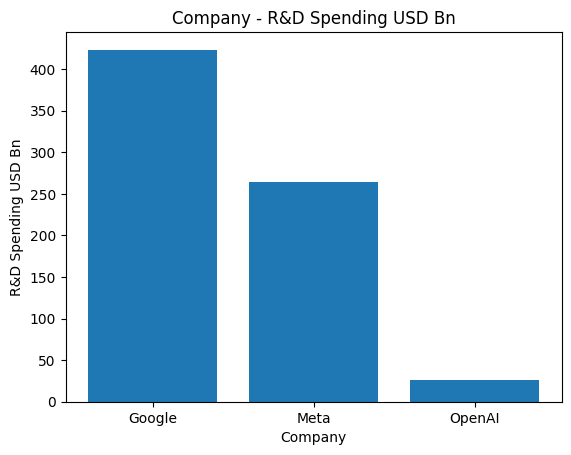

In [20]:
plt.bar(RD_Group_sum.index, RD_Group_sum.values)
plt.xlabel("Company")
plt.ylabel("R&D Spending USD Bn")
plt.title("Company - R&D Spending USD Bn")
plt.savefig("Figures/company_r&d_spending_usd.png")
plt.show()

2. How much **AI revenue** was earned by each company?  


In [17]:
data.columns

Index(['Date', 'Company', 'R&D_Spending_USD_Mn', 'AI_Revenue_USD_Mn',
       'AI_Revenue_Growth_%', 'Event', 'Stock_Impact_%', 'Year'],
      dtype='object')

In [18]:
AI_Group_sum = data.groupby("Company")["AI_Revenue_USD_Mn"].sum()/1000
AI_Group_sum

Company
Google    284.49838
Meta      189.62182
OpenAI      9.46289
Name: AI_Revenue_USD_Mn, dtype: float64

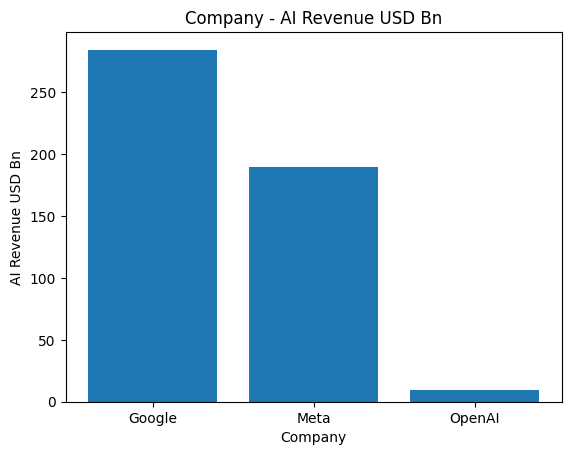

In [19]:
plt.bar(AI_Group_sum.index, AI_Group_sum.values)
plt.xlabel("Company")
plt.ylabel("AI Revenue USD Bn")
plt.title("Company - AI Revenue USD Bn")
plt.savefig("Figures/company_ai_revenue_usd.png")
plt.show()

3. What was the **date-wise impact on stock** performance?  


In [21]:
data.head()

,Date,Company,R&D_Spending_USD_Mn,AI_Revenue_USD_Mn,AI_Revenue_Growth_%,Event,Stock_Impact_%,Year
0,2015-01-01,OpenAI,5.92,0.63,-36.82,NaN,-0.36,2015
1,2015-01-02,OpenAI,5.41,1.81,80.59,NaN,0.41,2015
2,2015-01-03,OpenAI,4.50,0.61,-38.88,NaN,0.23,2015
3,2015-01-04,OpenAI,5.45,0.95,-5.34,NaN,0.93,2015
4,2015-01-05,OpenAI,3.40,1.48,48.45,NaN,-0.09,2015


4. Identify **events with maximum stock impact**.  


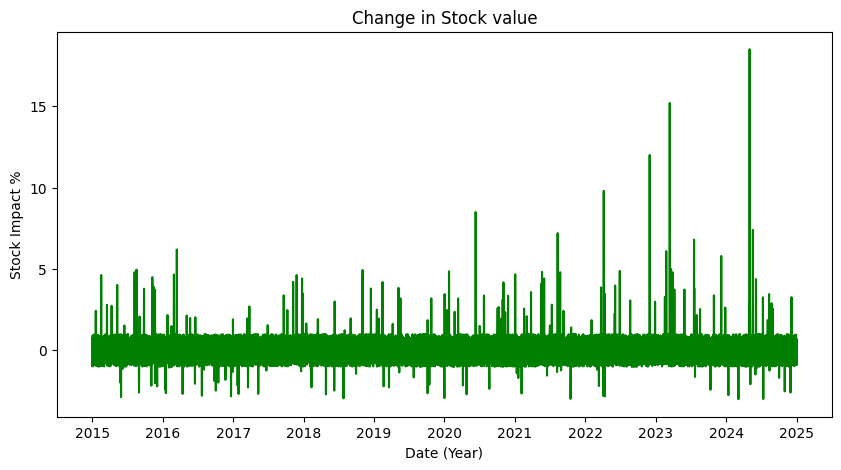

In [24]:
plt.figure(figsize=(10,5))
plt.plot(data["Date"],data["Stock_Impact_%"],color="green")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value")
plt.savefig("Figures/Stock_impact.png")
plt.show()

In [27]:
data["Company"].unique()

array(['OpenAI', 'Google', 'Meta'], dtype=object)

In [28]:
data_openAI = data[data["Company"]=="OpenAI"]
data_Google = data[data["Company"]=="Google"]
data_Meta = data[data["Company"]=="Meta"]

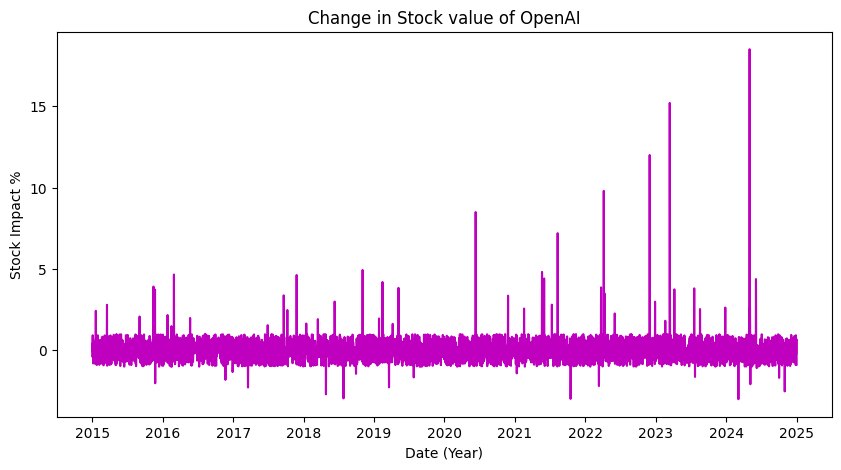

In [32]:
plt.figure(figsize=(10,5))
plt.plot(data_openAI["Date"],data_openAI["Stock_Impact_%"],color="m")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of OpenAI")
plt.savefig("Figures/Stock_impact_OpenAI.png")
plt.show()

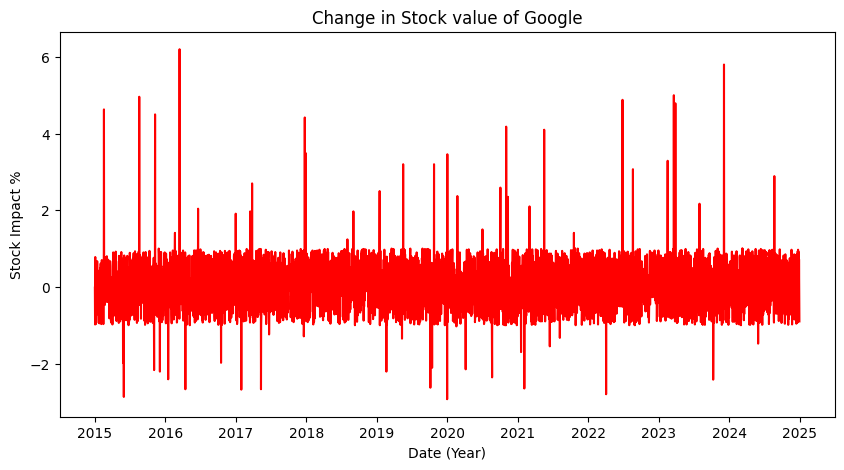

In [35]:
plt.figure(figsize=(10,5))
plt.plot(data_Google["Date"],data_Google["Stock_Impact_%"],color="r")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of Google")
plt.savefig("Figures/Stock_impact_Google.png")
plt.show()

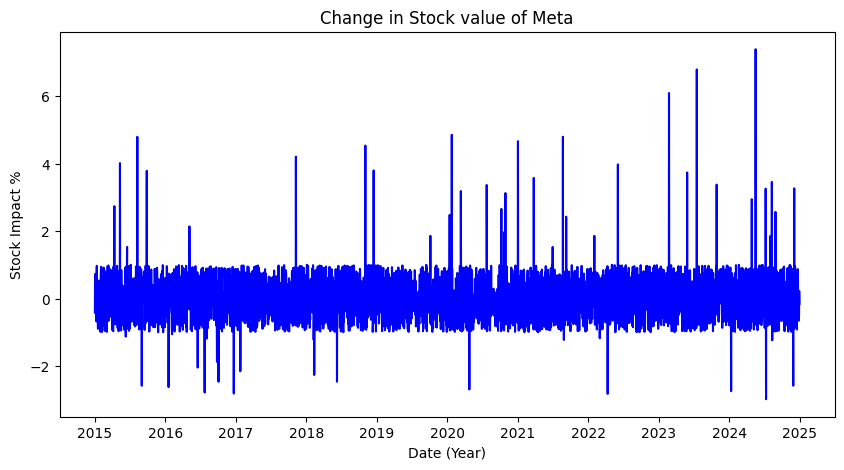

In [36]:
plt.figure(figsize=(10,5))
plt.plot(data_Meta["Date"],data_Meta["Stock_Impact_%"],color="b")
plt.xlabel("Date (Year)")
plt.ylabel("Stock Impact %")
plt.title("Change in Stock value of Meta")
plt.savefig("Figures/Stock_impact_Meta.png")
plt.show()

In [40]:
data_openAI[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
3408,2024-05-01,GPT-5 release (predicted),18.5


In [41]:
data_Google[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
4092,2016-03-15,AlphaGo beats Lee Sedol,6.2


In [42]:
data_Meta[["Date","Event","Stock_Impact_%"]].sort_values(by="Stock_Impact_%", ascending=False).head(1)

,Date,Event,Stock_Impact_%
10731,2024-05-18,LLaMA 3 release (predicted),7.4


5. Analyze **AI revenue growth trends** for each company.  


6. Compute **correlations** between columns.  


7. Compare **yearly expenditure vs revenue**.  


8. Perform **event impact analysis**.  


9. Track **changes in stock index** with respect to year and company.
